# Results Comparison

This notebook will evaluate and compare the performance of all of the models using Tensorboard and code-based metrics.

This notebook will also be used to analyse the balance/imbalance across all labelling categories (sign types as well as the four sign attributes), in order to document the distribution.

## Import Dependencies

In [1]:
import os
import json
from pathlib import Path
import zipfile
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt

In [2]:
%matplotlib inline

## Model Comparison

## Dataset Analysis

In [14]:
# paths
DATASET_ROOT = os.path.join('Dataset')
DATASET_SPLIT = os.path.join(DATASET_ROOT, 'Train-Test-Val Split')
COCO_DATA = os.path.join(DATASET_SPLIT, 'COCO-based')

In [4]:
# total images in dataset

zip_path = os.path.join(DATASET_ROOT, 'merged_images.zip')    # path to zipfile that contains all images

with zipfile.ZipFile(zip_path, 'r') as z:
    total_files = len(z.namelist())

print(f'Dataset contains {total_files} images in total.')

Dataset contains 715 images in total.


The dataset was split into Train/Validation/Test subsets using the provided LS2COCO.ipynb with a 70%/15%/15% split.

In [12]:
# total images in each train/val/test subset

zip_path = os.path.join(DATASET_SPLIT, 'images.zip')   # path to zip file containing dataset images

folder_counts = Counter()   # count files per sub folder

with zipfile.ZipFile(zip_path, "r") as z:
    for info in z.infolist():
        if info.is_dir():
            continue  # skip directories

        folder = os.path.dirname(info.filename)
        folder_counts[folder] += 1

for folder, count in folder_counts.items():
    print(f"{folder}: {count} images.")

images/test: 119 images.
images/train: 485 images.
images/val: 111 images.


### Dataset Class Distribution

In [26]:
# compute class distribution by number of annotations
# how many bounding boxes per class

def class_distribution(coco_path):
    with open(coco_path, "r") as f:
        coco = json.load(f)

    # class id to class name mapping
    id2name = {c["id"]: c["name"] for c in coco["categories"]}

    # count number of annotations per class
    counts = Counter()
    for ann in coco["annotations"]:
        counts[id2name[ann["category_id"]]] += 1

    return counts

#### Sign Type

In [27]:
sign_type_path = os.path.join(COCO_DATA, 'COCO-based_COCO', 'annotations')   # contains json coco annotation files

In [47]:
# class distribution

print('Class Distribution per split:')

all_dists = {}
total_dist = Counter()   # to keep class counts for the entire dataset

for coco_file in os.listdir(sign_type_path):
    dist = class_distribution(os.path.join(sign_type_path, coco_file))
    all_dists[coco_file] = dist
    total_dist += dist
        
    print(f"\n{coco_file}:\n")
    
    total = sum(dist.values())
    for cls, n in dist.most_common():
        print(f"{cls:30s}: {n} \t ({n/total:.2%})")

print('\nClass Distribution for entire dataset:\n')

total = sum(total_dist.values())
for cls, n in total_dist.most_common():
    print(f"{cls:30s}: {n} \t ({n/total:.2%})")


Class Distribution per split:

test.json:

No Entry (One Way)            : 49 	 (29.17%)
Stop                          : 34 	 (20.24%)
Blind-Spot Mirror (Convex)    : 33 	 (19.64%)
Pedestrian Crossing           : 25 	 (14.88%)
Roundabout Ahead              : 15 	 (8.93%)
No Through Road (T-Sign)      : 12 	 (7.14%)

train.json:

No Entry (One Way)            : 186 	 (26.12%)
Pedestrian Crossing           : 139 	 (19.52%)
Stop                          : 128 	 (17.98%)
Blind-Spot Mirror (Convex)    : 105 	 (14.75%)
Roundabout Ahead              : 93 	 (13.06%)
No Through Road (T-Sign)      : 61 	 (8.57%)

val.json:

No Entry (One Way)            : 41 	 (23.56%)
Pedestrian Crossing           : 38 	 (21.84%)
Blind-Spot Mirror (Convex)    : 37 	 (21.26%)
Stop                          : 30 	 (17.24%)
Roundabout Ahead              : 14 	 (8.05%)
No Through Road (T-Sign)      : 14 	 (8.05%)

Class Distribution for entire dataset:

No Entry (One Way)            : 276 	 (26.19%)
Pedestrian Cross

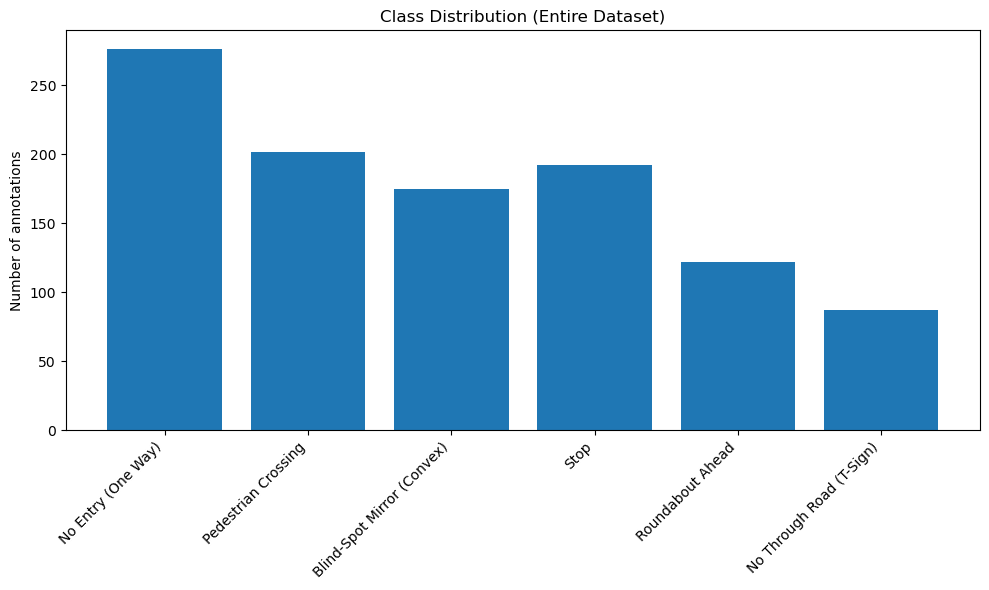

In [68]:
classes = list(total_dist.keys())
counts = list(total_dist.values())

plt.figure(figsize=(10, 6))
plt.bar(classes, counts)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Number of annotations")
plt.title("Class Distribution (Entire Dataset)")
plt.tight_layout()
plt.show()

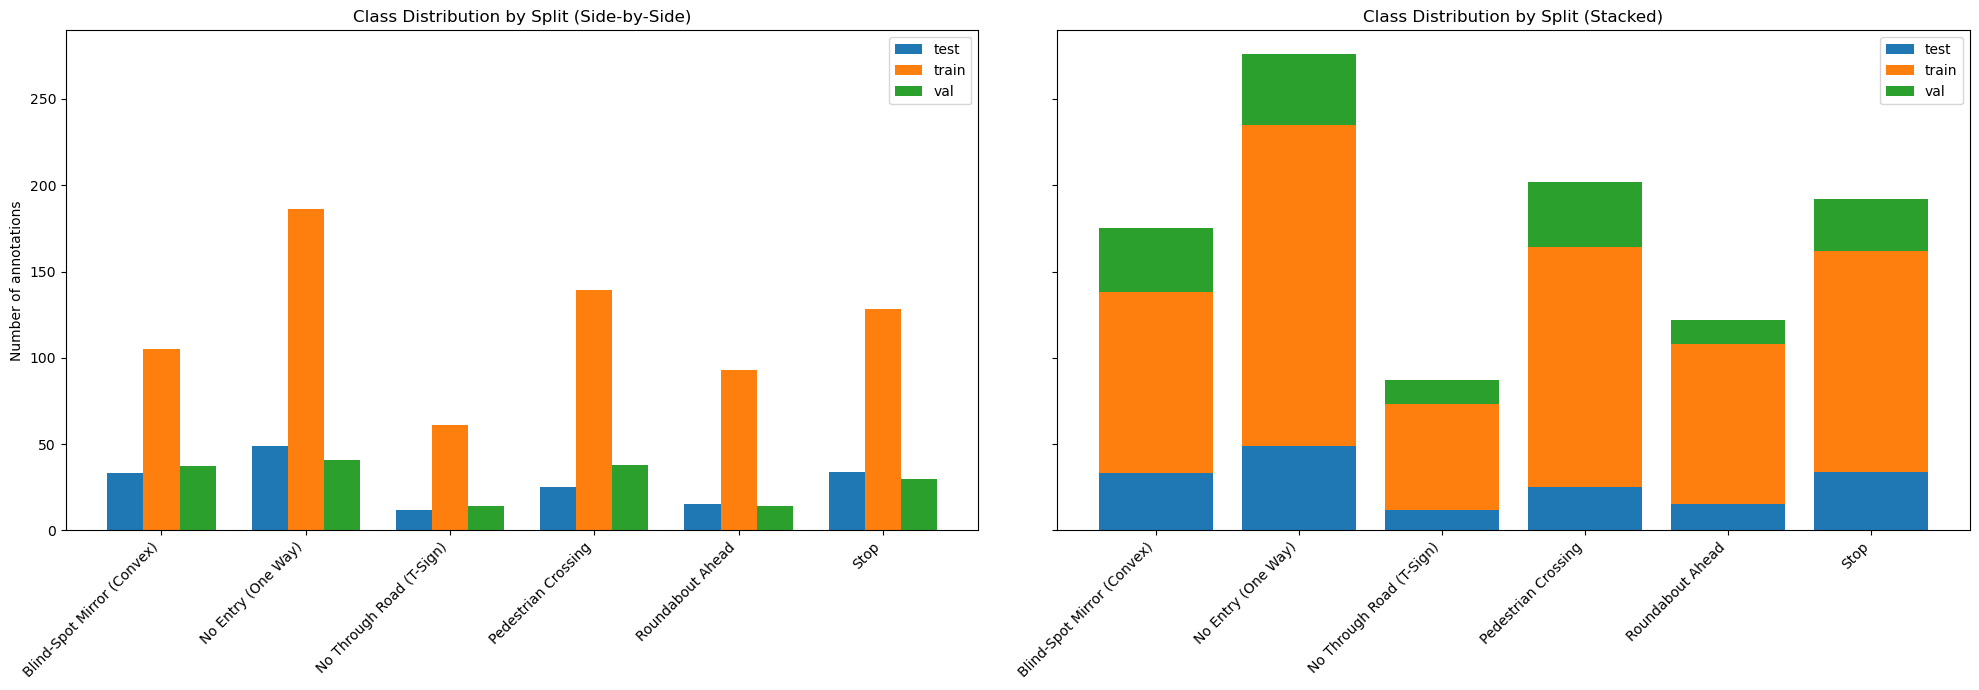

In [61]:
classes = sorted(total_dist.keys())
splits = list(all_dists.keys())       # train, test, val

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 7), sharey=True)

# side-by-side bars (on the left)

x = np.arange(len(classes))       # class positions
width = 0.25                      # bar width

for i, split in enumerate(splits):
    counts = [all_dists[split].get(cls, 0) for cls in classes]
    ax1.bar(x + i * width, counts, width=width, label=split.replace(".json", ""))

ax1.set_xticks(x + width)
ax1.set_xticklabels(classes, rotation=45, ha="right")
ax1.set_title("Class Distribution by Split (Side-by-Side)")
ax1.set_ylabel("Number of annotations")
ax1.legend()

# stacked bars (right)

bottom = np.zeros(len(classes))

for split in splits:
    counts = [all_dists[split].get(cls, 0) for cls in classes]
    ax2.bar(x, counts, bottom=bottom, label=split.replace(".json", ""))
    bottom += counts

ax2.set_xticks(x)
ax2.set_xticklabels(classes, rotation=45, ha="right")
ax2.set_title("Class Distribution by Split (Stacked)")
ax2.legend()

plt.tight_layout()
plt.show()

In [ ]:
# compute class distribution by images
# how many images contain at least one instance of each class



In [ ]:
# compute per-split comparison
# see if train / val / test are balanced or imbalanced



#### Viewing Angle

In [69]:
viewing_angle_path = os.path.join(COCO_DATA, 'COCO-based_COCO_view_angle', 'annotations')

In [70]:
# class distribution

print('Class Distribution per split:')

all_dists = {}
total_dist = Counter()   # to keep class counts for the entire dataset

for coco_file in os.listdir(viewing_angle_path):
    dist = class_distribution(os.path.join(viewing_angle_path, coco_file))
    all_dists[coco_file] = dist
    total_dist += dist
        
    print(f"\n{coco_file}:\n")
    
    total = sum(dist.values())
    for cls, n in dist.most_common():
        print(f"{cls:30s}: {n} \t ({n/total:.2%})")

print('\nClass Distribution for entire dataset:\n')

total = sum(total_dist.values())
for cls, n in total_dist.most_common():
    print(f"{cls:30s}: {n} \t ({n/total:.2%})")


Class Distribution per split:

test.json:

Side                          : 60 	 (35.71%)
Front                         : 57 	 (33.93%)
Back                          : 51 	 (30.36%)

train.json:

Front                         : 291 	 (40.87%)
Back                          : 219 	 (30.76%)
Side                          : 202 	 (28.37%)

val.json:

Front                         : 71 	 (40.80%)
Side                          : 52 	 (29.89%)
Back                          : 51 	 (29.31%)

Class Distribution for entire dataset:

Front                         : 419 	 (39.75%)
Back                          : 321 	 (30.46%)
Side                          : 314 	 (29.79%)


#### Mounting Type

In [71]:
mounting_type_path = os.path.join(COCO_DATA, 'COCO-based_COCO_mounting', 'annotations')

In [72]:
# class distribution

print('Class Distribution per split:')

all_dists = {}
total_dist = Counter()   # to keep class counts for the entire dataset

for coco_file in os.listdir(mounting_type_path):
    dist = class_distribution(os.path.join(mounting_type_path, coco_file))
    all_dists[coco_file] = dist
    total_dist += dist
        
    print(f"\n{coco_file}:\n")
    
    total = sum(dist.values())
    for cls, n in dist.most_common():
        print(f"{cls:30s}: {n} \t ({n/total:.2%})")

print('\nClass Distribution for entire dataset:\n')

total = sum(total_dist.values())
for cls, n in total_dist.most_common():
    print(f"{cls:30s}: {n} \t ({n/total:.2%})")


Class Distribution per split:

test.json:

Pole-mounted                  : 147 	 (87.50%)
Wall-mounted                  : 21 	 (12.50%)

train.json:

Pole-mounted                  : 621 	 (87.22%)
Wall-mounted                  : 91 	 (12.78%)

val.json:

Pole-mounted                  : 149 	 (85.63%)
Wall-mounted                  : 25 	 (14.37%)

Class Distribution for entire dataset:

Pole-mounted                  : 917 	 (87.00%)
Wall-mounted                  : 137 	 (13.00%)


#### Sign Condition

In [73]:
sign_condition_path = os.path.join(COCO_DATA, 'COCO-based_COCO_condition', 'annotations')

In [74]:
# class distribution

print('Class Distribution per split:')

all_dists = {}
total_dist = Counter()   # to keep class counts for the entire dataset

for coco_file in os.listdir(sign_condition_path):
    dist = class_distribution(os.path.join(sign_condition_path, coco_file))
    all_dists[coco_file] = dist
    total_dist += dist
        
    print(f"\n{coco_file}:\n")
    
    total = sum(dist.values())
    for cls, n in dist.most_common():
        print(f"{cls:30s}: {n} \t ({n/total:.2%})")

print('\nClass Distribution for entire dataset:\n')

total = sum(total_dist.values())
for cls, n in total_dist.most_common():
    print(f"{cls:30s}: {n} \t ({n/total:.2%})")


Class Distribution per split:

test.json:

Good                          : 113 	 (67.26%)
Weathered                     : 49 	 (29.17%)
Heavily Damaged               : 6 	 (3.57%)

train.json:

Good                          : 477 	 (66.99%)
Weathered                     : 206 	 (28.93%)
Heavily Damaged               : 29 	 (4.07%)

val.json:

Good                          : 117 	 (67.24%)
Weathered                     : 52 	 (29.89%)
Heavily Damaged               : 5 	 (2.87%)

Class Distribution for entire dataset:

Good                          : 707 	 (67.08%)
Weathered                     : 307 	 (29.13%)
Heavily Damaged               : 40 	 (3.80%)


#### Sign Shape Type

In [75]:
sign_shape_path = os.path.join(COCO_DATA, 'COCO-based_COCO_sign_shape', 'annotations')

In [76]:
# class distribution

print('Class Distribution per split:')

all_dists = {}
total_dist = Counter()   # to keep class counts for the entire dataset

for coco_file in os.listdir(sign_shape_path):
    dist = class_distribution(os.path.join(sign_shape_path, coco_file))
    all_dists[coco_file] = dist
    total_dist += dist
        
    print(f"\n{coco_file}:\n")
    
    total = sum(dist.values())
    for cls, n in dist.most_common():
        print(f"{cls:30s}: {n} \t ({n/total:.2%})")

print('\nClass Distribution for entire dataset:\n')

total = sum(total_dist.values())
for cls, n in total_dist.most_common():
    print(f"{cls:30s}: {n} \t ({n/total:.2%})")


Class Distribution per split:

test.json:

Circular                      : 89 	 (52.98%)
Octagonal                     : 34 	 (20.24%)
Square                        : 28 	 (16.67%)
Triangular                    : 15 	 (8.93%)
Damaged                       : 2 	 (1.19%)

train.json:

Circular                      : 334 	 (46.91%)
Square                        : 149 	 (20.93%)
Octagonal                     : 121 	 (16.99%)
Triangular                    : 84 	 (11.80%)
Damaged                       : 24 	 (3.37%)

val.json:

Circular                      : 89 	 (51.15%)
Square                        : 39 	 (22.41%)
Octagonal                     : 30 	 (17.24%)
Triangular                    : 13 	 (7.47%)
Damaged                       : 3 	 (1.72%)

Class Distribution for entire dataset:

Circular                      : 512 	 (48.58%)
Square                        : 216 	 (20.49%)
Octagonal                     : 185 	 (17.55%)
Triangular                    : 112 	 (10.63%)
Damaged         